# Why we divide by n - 1 in variance

# Why We Divide by $n - 1$ for Sample Variance
### *Insights from Justin Helps’s Simulation (Khan Academy)*

This document summarizes the simulation created by Justin Helps to demonstrate why dividing by $n - 1$ (Bessel's Correction) provides an unbiased estimate of population variance.

---

## 1. The Simulation Setup
The simulation tests how different denominators affect the accuracy of variance estimates:
*   **Population:** A flat, uniform distribution from 0 to 100.
*   **Sampling:** Repeatedly drawing samples of size $n = 50$.
*   **Estimators Tested:**
    1.  **Biased Variance:** Dividing by $n$
    2.  **Unbiased Variance:** Dividing by $n - 1$
    3.  **Over-corrected Variance:** Dividing by $n - 2$

## 2. Key Findings
As the number of samples increases, the simulation tracks the mean of these variances to see which converges to the true population variance:
*   **Dividing by $n$:** Consistently **underestimates** the true variance.
*   **Dividing by $n - 1$:** Accurately **converges** to the true population variance.
*   **Dividing by $n - 2$:** Consistently **overestimates** the true variance.

## 3. Visualizing the Bias
The simulation uses a coordinate system to explain *why* the underestimation occurs when using the sample mean:



| **Axis** | **Metric** |
| --- | --- |
| **Horizontal** (𝑥) | The distance between the **Sample Mean** (x̄) and the **True Mean** (𝜇). |
| **Vertical** (𝑦) | The difference between variance calculated with x̄ vs. variance calculated with 𝜇ulation variance.

## The "Shape" of Bias

The plot shows that when we use the sample mean (x̄) to calculate variance:

-   Every data point falls **below the horizontal axis**.
-   This proves that calculating variance relative to the sample mean _always_ results in a lower value than calculating it relative to the true population mean.
-   The sample mean "centers" itself within the sample data, which artificially reduces the perceived spread.

## 4\. Conclusion: The Purpose of 𝑛−1

-   **The Problem:** Using the sample mean instead of the true population mean systematically underestimates the "true" variability of the population.
-   **The Solution:** Dividing by 𝑛−1 instead of 𝑛 increases the result of the calculation just enough to compensate for that downward bias.
-   **The Result:** An **unbiased estimator**, where the average of many sample variances equals the true population variance.


# **Why We Divide by _n − 1_ to Estimate Population Variance**  
### *(Summary Based on Justin Helps’s Simulation)*

Justin Helps created a simulation to demonstrate why dividing by **n − 1** (Bessel’s correction) produces an **unbiased estimate** of the population variance. The simulation compares variance estimates calculated using denominators **n**, **n − 1**, and **n − 2**.

---

## **1. Simulation Setup**

- **Population distribution:** Uniform from 0 to 100  
- **Sample size:** 50  
- For each sample, compute three different variance estimates:
  - Variance using **n**
  - Variance using **n − 1**
  - Variance using **n − 2**
- Repeat this for many samples and compute the **mean variance** for each method.

---

## **2. Simulation Results**

### **Dividing by n**
- The average variance **underestimates** the true population variance.
- This underestimation persists even with very large numbers of samples.

### **Dividing by n − 1**
- The average variance **converges exactly** to the true population variance.
- This shows the estimator is **unbiased**.

### **Dividing by n − 2**
- The average variance **overestimates** the true population variance.

**Conclusion:**  
The correct adjustment to remove bias from using the sample mean is dividing by **n − 1**.

---

## **3. Visual Interpretation of the Bias**

The simulation also includes a plot:

### **Axes**
- **Horizontal axis:** Difference between the sample mean and the *true* mean.  
- **Vertical axis:** Difference between:
  1. Variance using the **sample mean**  
  2. Variance using the **true population mean**

### **Observed Patterns**

- With denominator **n**, every point lies **below zero**, meaning:  
  > Using the sample mean *always* underestimates variance compared to using the population mean.

- With **n − 1**, points appear both above and below zero, meaning:  
  > Overestimation and underestimation balance out on average.

- With **n − 2**, points are mostly above zero, meaning:  
  > Systematic overestimation.

---

## **4. Why Bessel’s Correction Works**

Using the sample mean makes the data appear slightly less spread out because the sample mean is optimized to minimize squared deviations. This artificially lowers variance.

Dividing by **n − 1** corrects this systematic bias:

```
Unbiased sample variance = (1 / (n − 1)) * Σ (xi − x̄)²
```

This is known as **Bessel’s correction**.

---



True Population Variance: 831.40
Mean Variance (n):         819.18 (Underestimates)
Mean Variance (n-1):       835.90 (Unbiased)
Mean Variance (n-2):       853.31 (Overestimates)


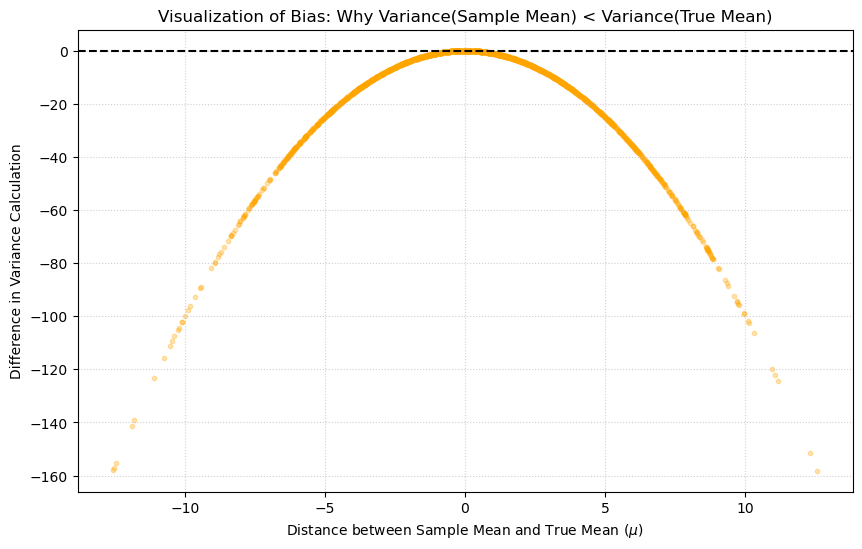

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Simulation Parameters
np.random.seed(42)  # For reproducibility
population_size = 100000
pop_low, pop_high = 0, 100
sample_size = 50
num_samples = 2000

# Create the uniform population
population = np.random.uniform(pop_low, pop_high, population_size)
true_variance = np.var(population)
true_mean = np.mean(population)

# 2. Run the Simulation
variances_n = []
variances_n_minus_1 = []
variances_n_minus_2 = []
mean_diffs = []
variance_diffs = []

for _ in range(num_samples):
    sample = np.random.choice(population, sample_size)
    sample_mean = np.mean(sample)
    
    # Calculate sum of squared deviations from sample mean
    ss = np.sum((sample - sample_mean)**2)
    
    # Calculate variance using the three denominators
    variances_n.append(ss / sample_size)
    variances_n_minus_1.append(ss / (sample_size - 1))
    variances_n_minus_2.append(ss / (sample_size - 2))
    
    # For the visualization plot:
    # X-axis: Difference between Sample Mean and True Mean
    # Y-axis: (Variance using sample mean) - (Variance using true mean)
    ss_true_mean = np.sum((sample - true_mean)**2)
    mean_diffs.append(sample_mean - true_mean)
    variance_diffs.append((ss / sample_size) - (ss_true_mean / sample_size))

# 3. Print Convergence Results
print(f"True Population Variance: {true_variance:.2f}")
print(f"Mean Variance (n):         {np.mean(variances_n):.2f} (Underestimates)")
print(f"Mean Variance (n-1):       {np.mean(variances_n_minus_1):.2f} (Unbiased)")
print(f"Mean Variance (n-2):       {np.mean(variances_n_minus_2):.2f} (Overestimates)")

# 4. Visualization (The "Shape of Bias")
plt.figure(figsize=(10, 6))
plt.scatter(mean_diffs, variance_diffs, alpha=0.3, color='orange', s=10)
plt.axhline(0, color='black', linestyle='--')
plt.title("Visualization of Bias: Why Variance(Sample Mean) < Variance(True Mean)")
plt.xlabel("Distance between Sample Mean and True Mean ($\mu$)")
plt.ylabel("Difference in Variance Calculation")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()


## What this Python script does: 

1.  **Simulates the Population:** Creates a flat distribution from 0 to 100, just like the simulation described.
2.  **Iterative Sampling:** It draws 2,000 different samples of 50 items each.
3.  **Applies Bessel's Correction:** It calculates variance using 𝑛, 𝑛−1, and 𝑛−2 for every sample.
4.  **Demonstrates Bias:** The scatter plot displays the "Vertical Axis" logic from your summary. Notice that **every single point** in the scatter plot is below zero. This visually proves that using the sample mean _always_ results in a lower sum of squares than using the true population mean, necessitating the 𝑛−1 correction. 

### Documentation 

For more advanced statistical functions in 2025, you can use the NumPy var documentation (note the **_ddof_** parameter) or the Pandas **_var_** documentation which defaults to 𝑛−1.

# [Context](https://github.com/progressivepull/Statistics-Deep-Dives/blob/main/khan_academy/Content.md)